# Mixture of LoRA Experts (MoLE) — Children's Speech ASR

This notebook implements a **Mixture of LoRA Experts** approach for age-adaptive ASR:

1. **Three age-specific LoRA adapters** (from `notebook_whisper_age_specific.ipynb`) are loaded into a single PeftModel.
2. A **gating MLP** is trained on frozen Whisper encoder features to predict the child's age-bucket probabilities.
3. At inference, the predicted probabilities are used to **dynamically merge** the three adapters via `add_weighted_adapter` (linear combination of the ΔW matrices).
4. WER is compared across four strategies: zero-shot, oracle routing (true age), hard gate routing (argmax), and soft MoLE (weighted merge).


In [9]:
# Set cache directories (UCL lab machines)
import os
os.environ['HF_HOME']       = '/cs/student/project_msc/2025/dsml/nmxian/.cache/huggingface'
os.environ['TORCH_HOME']    = '/cs/student/project_msc/2025/dsml/nmxian/.cache/torch'
os.environ['KAGGLEHUB_CACHE'] = '/cs/student/project_msc/2025/dsml/nmxian/.cache/kagglehub'


In [10]:
# ── 0. Install required libraries ────────────────────────────────────────────
#!pip install -q transformers datasets soundfile librosa jiwer scikit-learn accelerate peft numpy pandas matplotlib


In [11]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import os, json, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import soundfile as sf
import librosa
import jiwer
from sklearn.metrics import confusion_matrix, classification_report

from transformers import WhisperProcessor, WhisperForConditionalGeneration
from peft import PeftModel

print(f"torch : {torch.__version__}")
print(f"CUDA  : {torch.cuda.is_available()}")
import peft; print(f"peft  : {peft.__version__}")


torch : 2.8.0+cu128
CUDA  : True
peft  : 0.17.1


In [12]:
# ── 2. Configuration ─────────────────────────────────────────────────────────
DATA_ROOT        = Path("/cs/student/project_msc/2025/dsml/nmxian/comp0197-cw2")
MODEL_NAME       = "openai/whisper-small"
SAMPLE_RATE      = 16_000
MAX_DURATION_SEC = 30.0

AGE_BUCKETS    = ["3-4", "5-7", "8-11"]
AGE_BUCKET_MAP = {"3-4": 0, "5-7": 1, "8-11": 2}
ADAPTER_NAMES  = ["age_3_4", "age_5_7", "age_8_11"]

ADAPTER_DIRS = {
    "3-4":  DATA_ROOT / "whisper_lora_age_3_4",
    "5-7":  DATA_ROOT / "whisper_lora_age_5_7",
    "8-11": DATA_ROOT / "whisper_lora_age_8_11",
}

# Gating MLP
ENCODER_DIM     = 768     # whisper-small d_model
GATE_HIDDEN     = 256
GATE_DROPOUT    = 0.1
GATE_LR         = 1e-3
GATE_EPOCHS     = 10
GATE_BATCH_SIZE = 32
GATE_TRAIN_N    = 10_000  # subsample for gate training (MLP doesn't need 60K+)
GATE_EVAL_N     = 2_000

NUM_BEAMS          = 5
# EVAL_N_PER_BUCKET  = 200
OUTPUT_DIR         = str(DATA_ROOT / "whisper_mole")
SEED               = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Verify adapter directories exist
for bucket, path in ADAPTER_DIRS.items():
    assert path.exists(), f"Adapter dir not found: {path} — run notebook_whisper_age_specific.ipynb first"
print("All adapter directories found.")


Device: cuda
All adapter directories found.


In [13]:
# ── 3. Load speaker-independent splits ───────────────────────────────────────
def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

train_raw = load_jsonl(DATA_ROOT / "train_word_transcripts_spkind.jsonl")
val_raw   = load_jsonl(DATA_ROOT / "val_word_transcripts_spkind.jsonl")
test_raw  = load_jsonl(DATA_ROOT / "test_word_transcripts_spkind.jsonl")

print(f"Train: {len(train_raw):,}  Val: {len(val_raw):,}  Test: {len(test_raw):,}")


Train: 67,041  Val: 14,308  Test: 14,223


In [14]:
# ── 4. Filter by duration ────────────────────────────────────────────────────
def filter_duration(records, max_sec=MAX_DURATION_SEC):
    return [r for r in records if r["audio_duration_sec"] <= max_sec]

train_data = filter_duration(train_raw)
eval_data  = filter_duration(val_raw)
test_data  = filter_duration(test_raw)

print(f"After filtering (≤{MAX_DURATION_SEC}s):")
print(f"  Train: {len(train_data):,}  Eval: {len(eval_data):,}  Test: {len(test_data):,}")
for bucket in AGE_BUCKETS:
    n = sum(1 for d in test_data if d["age_bucket"] == bucket)
    print(f"  Test [{bucket}]: {n:,}")


After filtering (≤30.0s):
  Train: 65,337  Eval: 14,079  Test: 13,964
  Test [3-4]: 1,571
  Test [5-7]: 1,718
  Test [8-11]: 10,675


In [15]:
# ── 5. Audio & WER utilities ─────────────────────────────────────────────────
def load_audio(audio_path_rel):
    path = DATA_ROOT / audio_path_rel
    audio, sr = sf.read(str(path))
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    if sr != SAMPLE_RATE:
        audio = librosa.resample(audio.astype(np.float32),
                                 orig_sr=sr, target_sr=SAMPLE_RATE)
    return audio.astype(np.float32)

_transform = jiwer.Compose([
    jiwer.RemoveMultipleSpaces(),
    jiwer.Strip(),
    jiwer.ToLowerCase(),
    jiwer.ReduceToListOfListOfWords(),
])

def wer_score(refs, preds):
    out = jiwer.process_words(
        refs, preds,
        reference_transform=_transform,
        hypothesis_transform=_transform,
    )
    return out.wer


In [16]:
# ── 6. Load processor & base model ───────────────────────────────────────────
processor = WhisperProcessor.from_pretrained(
    MODEL_NAME, language="English", task="transcribe"
)

base_model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)

forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="english", task="transcribe"
)
base_model.config.forced_decoder_ids   = forced_decoder_ids
base_model.config.suppress_tokens      = []
base_model.generation_config.language   = "english"
base_model.generation_config.task       = "transcribe"
base_model.generation_config.forced_decoder_ids = forced_decoder_ids

print(f"Base model loaded: {MODEL_NAME}")


Base model loaded: openai/whisper-small


In [17]:
# ── 7. Load three age-specific LoRA adapters ─────────────────────────────────
# The first adapter creates the PeftModel wrapper; subsequent adapters are
# loaded into the same model as named adapters.
model = PeftModel.from_pretrained(
    base_model, str(ADAPTER_DIRS["3-4"]), adapter_name="age_3_4"
)
model.load_adapter(str(ADAPTER_DIRS["5-7"]),  adapter_name="age_5_7")
model.load_adapter(str(ADAPTER_DIRS["8-11"]), adapter_name="age_8_11")

model = model.to(device).eval()
print(f"Loaded adapters: {list(model.peft_config.keys())}")

# Quick param count
for name in ADAPTER_NAMES:
    model.set_adapter(name)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  {name}: {trainable:,} trainable params")


/cs/student/project_msc/2025/dsml/nmxian/my-notebook/myenv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


Loaded adapters: ['age_3_4', 'age_5_7', 'age_8_11']
  age_3_4: 1,769,472 trainable params
  age_5_7: 1,769,472 trainable params
  age_8_11: 1,769,472 trainable params


In [18]:
# ── 8. Extract frozen encoder features for gate training ─────────────────────
# The gating MLP operates on BASE encoder features (no LoRA), so it is
# independent of which adapter is active.

def extract_features(data, model, processor, device, batch_size=GATE_BATCH_SIZE):
    model.eval()
    all_features, all_labels = [], []

    for i in range(0, len(data), batch_size):
        batch = data[i:i + batch_size]
        audios = [load_audio(item["audio_path"]) for item in batch]

        inputs = processor.feature_extractor(
            audios, sampling_rate=SAMPLE_RATE, return_tensors="pt", padding="max_length"
        )
        input_features = inputs.input_features.to(device)

        with model.disable_adapter(), torch.no_grad():
            encoder = model.base_model.model.get_encoder()
            enc_out = encoder(input_features)
            pooled  = enc_out.last_hidden_state.mean(dim=1)   # (B, 768)

        all_features.append(pooled.cpu())
        all_labels.extend(AGE_BUCKET_MAP[item["age_bucket"]] for item in batch)

        if (i // batch_size) % 100 == 0:
            print(f"  {i + len(batch):,} / {len(data):,}")

    return torch.cat(all_features), torch.tensor(all_labels)

# Subsample for efficiency
gate_train = random.sample(train_data, min(GATE_TRAIN_N, len(train_data)))
gate_eval  = random.sample(eval_data,  min(GATE_EVAL_N,  len(eval_data)))

print(f"Gate train samples: {len(gate_train):,}")
print(f"Gate eval samples:  {len(gate_eval):,}")

print("\nExtracting train features...")
train_feats, train_labels = extract_features(gate_train, model, processor, device)
print(f"  Shape: {train_feats.shape}")

print("Extracting eval features...")
eval_feats, eval_labels = extract_features(gate_eval, model, processor, device)
print(f"  Shape: {eval_feats.shape}")


Gate train samples: 10,000
Gate eval samples:  2,000

Extracting train features...
  32 / 10,000
  3,232 / 10,000
  6,432 / 10,000
  9,632 / 10,000
  Shape: torch.Size([10000, 768])
Extracting eval features...
  32 / 2,000
  Shape: torch.Size([2000, 768])


In [19]:
# ── 9. Define & train gating MLP ─────────────────────────────────────────────
class GatingMLP(nn.Module):
    def __init__(self, d_model, n_classes, hidden, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        return self.net(x)

gate = GatingMLP(ENCODER_DIM, len(AGE_BUCKETS), GATE_HIDDEN, GATE_DROPOUT).to(device)
optimizer = torch.optim.Adam(gate.parameters(), lr=GATE_LR)
criterion = nn.CrossEntropyLoss()

for epoch in range(GATE_EPOCHS):
    gate.train()
    perm = torch.randperm(len(train_feats))
    epoch_loss, correct = 0.0, 0

    for i in range(0, len(train_feats), GATE_BATCH_SIZE):
        idx = perm[i:i + GATE_BATCH_SIZE]
        x = train_feats[idx].to(device)
        y = train_labels[idx].to(device)

        logits = gate(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * len(idx)
        correct += (logits.argmax(-1) == y).sum().item()

    train_acc = correct / len(train_feats)

    gate.eval()
    with torch.no_grad():
        eval_logits = gate(eval_feats.to(device))
        eval_acc = (eval_logits.argmax(-1) == eval_labels.to(device)).float().mean().item()

    print(f"Epoch {epoch+1:2d}/{GATE_EPOCHS}  "
          f"loss={epoch_loss/len(train_feats):.4f}  "
          f"train_acc={train_acc:.4f}  eval_acc={eval_acc:.4f}")

# Save gate weights + config so it can be reloaded without hardcoding dims
os.makedirs(OUTPUT_DIR, exist_ok=True)
gate_path = os.path.join(OUTPUT_DIR, "gate_mlp.pt")
gate_config = {
    "d_model": ENCODER_DIM,
    "n_classes": len(AGE_BUCKETS),
    "hidden": GATE_HIDDEN,
    "dropout": GATE_DROPOUT,
    "age_buckets": AGE_BUCKETS,
    "adapter_names": ADAPTER_NAMES,
}
torch.save({"state_dict": gate.state_dict(), "config": gate_config}, gate_path)
print(f"\nGate saved to {gate_path}")
print(f"  Config: {gate_config}")


Epoch  1/10  loss=0.1887  train_acc=0.9271  eval_acc=0.9765
Epoch  2/10  loss=0.0559  train_acc=0.9817  eval_acc=0.9885
Epoch  3/10  loss=0.0466  train_acc=0.9831  eval_acc=0.9905
Epoch  4/10  loss=0.0351  train_acc=0.9880  eval_acc=0.9915
Epoch  5/10  loss=0.0361  train_acc=0.9874  eval_acc=0.9875
Epoch  6/10  loss=0.0285  train_acc=0.9899  eval_acc=0.9905
Epoch  7/10  loss=0.0293  train_acc=0.9895  eval_acc=0.9900
Epoch  8/10  loss=0.0290  train_acc=0.9894  eval_acc=0.9915
Epoch  9/10  loss=0.0245  train_acc=0.9917  eval_acc=0.9900
Epoch 10/10  loss=0.0234  train_acc=0.9927  eval_acc=0.9900

Gate saved to /cs/student/project_msc/2025/dsml/nmxian/comp0197-cw2/whisper_mole/gate_mlp.pt
  Config: {'d_model': 768, 'n_classes': 3, 'hidden': 256, 'dropout': 0.1, 'age_buckets': ['3-4', '5-7', '8-11'], 'adapter_names': ['age_3_4', 'age_5_7', 'age_8_11']}


Gate Classification Report:

              precision    recall  f1-score   support

         3-4       0.98      1.00      0.99       217
         5-7       0.96      0.99      0.97       243
        8-11       1.00      0.99      0.99      1540

    accuracy                           0.99      2000
   macro avg       0.98      0.99      0.98      2000
weighted avg       0.99      0.99      0.99      2000



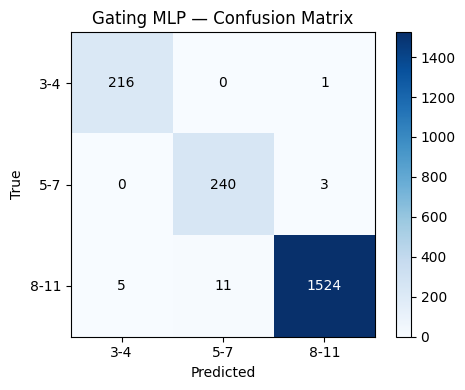

In [20]:
# ── 10. Gate accuracy & confusion matrix ─────────────────────────────────────
gate.eval()
with torch.no_grad():
    eval_preds = gate(eval_feats.to(device)).argmax(-1).cpu().numpy()
    eval_true  = eval_labels.numpy()

print("Gate Classification Report:\n")
print(classification_report(eval_true, eval_preds, target_names=AGE_BUCKETS))

cm = confusion_matrix(eval_true, eval_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set(xticks=range(3), yticks=range(3),
       xticklabels=AGE_BUCKETS, yticklabels=AGE_BUCKETS,
       xlabel="Predicted", ylabel="True",
       title="Gating MLP — Confusion Matrix")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i,j]}", ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.savefig(DATA_ROOT / "mole_gate_confusion.png", dpi=100)
plt.show()


In [21]:
# ── 11. Inference helpers ────────────────────────────────────────────────────

def get_gate_weights(audio, model, gate, processor, device):
    """Run frozen encoder + gating MLP → softmax weights over adapters."""
    feat = processor.feature_extractor(
        audio, sampling_rate=SAMPLE_RATE, return_tensors="pt"
    )
    input_features = feat.input_features.to(device)

    with model.disable_adapter(), torch.no_grad():
        enc_out = model.base_model.model.get_encoder()(input_features)
        pooled  = enc_out.last_hidden_state.mean(dim=1)

    gate.eval()
    with torch.no_grad():
        probs = torch.softmax(gate(pooled), dim=-1).squeeze(0).cpu().tolist()

    return probs   # [w_3-4, w_5-7, w_8-11]


def mole_transcribe(audio, model, gate, processor, device,
                    num_beams=NUM_BEAMS, max_new_tokens=225):
    """Transcribe with soft Mixture of LoRA Experts (weighted adapter merge)."""
    weights = get_gate_weights(audio, model, gate, processor, device)

    feat = processor.feature_extractor(
        audio, sampling_rate=SAMPLE_RATE, return_tensors="pt"
    )
    input_features = feat.input_features.to(device)

    # Merge adapters with predicted weights
    model.set_adapter(ADAPTER_NAMES[0])         # switch away from merged before deleting
    try:
        model.delete_adapter("mole_merged")
    except ValueError:
        pass

    model.add_weighted_adapter(
        adapters=ADAPTER_NAMES,
        weights=weights,
        adapter_name="mole_merged",
        combination_type="linear",
    )
    model.set_adapter("mole_merged")

    with torch.no_grad():
        ids = model.generate(
            input_features=input_features,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
        )

    text = processor.tokenizer.decode(ids[0], skip_special_tokens=True)
    return text, dict(zip(AGE_BUCKETS, weights))


def hard_route_transcribe(audio, model, adapter_name, processor, device,
                          num_beams=NUM_BEAMS, max_new_tokens=225):
    """Transcribe using a single adapter (hard routing)."""
    feat = processor.feature_extractor(
        audio, sampling_rate=SAMPLE_RATE, return_tensors="pt"
    )
    input_features = feat.input_features.to(device)

    model.set_adapter(adapter_name)
    with torch.no_grad():
        ids = model.generate(
            input_features=input_features,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
        )
    return processor.tokenizer.decode(ids[0], skip_special_tokens=True)


def zero_shot_transcribe(audio, model, processor, device,
                         num_beams=NUM_BEAMS, max_new_tokens=225):
    """Transcribe with all adapters disabled (base model)."""
    feat = processor.feature_extractor(
        audio, sampling_rate=SAMPLE_RATE, return_tensors="pt"
    )
    input_features = feat.input_features.to(device)

    with model.disable_adapter(), torch.no_grad():
        ids = model.generate(
            input_features=input_features,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
        )
    return processor.tokenizer.decode(ids[0], skip_special_tokens=True)

print("Inference helpers defined.")


Inference helpers defined.


In [22]:
# ── 12. Evaluate MoLE (soft routing) WER ─────────────────────────────────────
print("Evaluating MoLE WER on test set...\n")
model.eval()
gate.eval()

mole_preds_all, mole_refs_all = [], []
mole_wer_by_bucket = {}
gate_weight_log = []

for bucket in AGE_BUCKETS:
    bucket_data = [d for d in test_data if d["age_bucket"] == bucket][:]
    preds, refs = [], []

    for item in bucket_data:
        audio = load_audio(item["audio_path"])
        text, weights = mole_transcribe(audio, model, gate, processor, device)
        preds.append(text)
        refs.append(item["orthographic_text"])
        gate_weight_log.append({"true_bucket": bucket, **weights})

    bucket_wer = wer_score(refs, preds)
    mole_wer_by_bucket[bucket] = bucket_wer
    mole_preds_all.extend(preds)
    mole_refs_all.extend(refs)
    print(f"  MoLE [{bucket}] WER = {bucket_wer:.4f}  (n={len(preds)})")

mole_wer_overall = wer_score(mole_refs_all, mole_preds_all)
print(f"\n  MoLE overall WER = {mole_wer_overall:.4f}")


Evaluating MoLE WER on test set...



The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


  MoLE [3-4] WER = 0.4285  (n=1571)
  MoLE [5-7] WER = 0.0527  (n=1718)
  MoLE [8-11] WER = 0.1069  (n=10675)

  MoLE overall WER = 0.1140


In [23]:
# ── 13. Baselines: zero-shot, oracle routing, hard gate routing ──────────────
bucket_to_adapter = dict(zip(AGE_BUCKETS, ADAPTER_NAMES))

# ── Zero-shot ────────────────────────────────────────────────────────────────
print("Zero-shot WER (base model, no adapter)...\n")
zs_wer_by_bucket = {}
zs_preds_all, zs_refs_all = [], []

for bucket in AGE_BUCKETS:
    bucket_data = [d for d in test_data if d["age_bucket"] == bucket][:]
    preds, refs = [], []
    for item in bucket_data:
        audio = load_audio(item["audio_path"])
        preds.append(zero_shot_transcribe(audio, model, processor, device))
        refs.append(item["orthographic_text"])
    zs_wer_by_bucket[bucket] = wer_score(refs, preds)
    zs_preds_all.extend(preds)
    zs_refs_all.extend(refs)
    print(f"  Zero-shot [{bucket}] WER = {zs_wer_by_bucket[bucket]:.4f}")

zs_wer_overall = wer_score(zs_refs_all, zs_preds_all)
print(f"  Zero-shot overall WER = {zs_wer_overall:.4f}")

# ── Oracle routing (true age → correct adapter) ─────────────────────────────
print("\nOracle routing WER (true age selects adapter)...\n")
oracle_wer_by_bucket = {}
oracle_preds_all, oracle_refs_all = [], []

for bucket in AGE_BUCKETS:
    bucket_data = [d for d in test_data if d["age_bucket"] == bucket][:]
    preds, refs = [], []
    for item in bucket_data:
        audio = load_audio(item["audio_path"])
        preds.append(hard_route_transcribe(audio, model, bucket_to_adapter[bucket],
                                           processor, device))
        refs.append(item["orthographic_text"])
    oracle_wer_by_bucket[bucket] = wer_score(refs, preds)
    oracle_preds_all.extend(preds)
    oracle_refs_all.extend(refs)
    print(f"  Oracle [{bucket}] WER = {oracle_wer_by_bucket[bucket]:.4f}")

oracle_wer_overall = wer_score(oracle_refs_all, oracle_preds_all)
print(f"  Oracle overall WER = {oracle_wer_overall:.4f}")

# ── Hard gate routing (gate argmax → single adapter) ─────────────────────────
print("\nHard gate routing WER (gate argmax selects adapter)...\n")
hard_wer_by_bucket = {}
hard_preds_all, hard_refs_all = [], []

for bucket in AGE_BUCKETS:
    bucket_data = [d for d in test_data if d["age_bucket"] == bucket][:]
    preds, refs = [], []
    for item in bucket_data:
        audio = load_audio(item["audio_path"])
        weights = get_gate_weights(audio, model, gate, processor, device)
        best_adapter = ADAPTER_NAMES[np.argmax(weights)]
        preds.append(hard_route_transcribe(audio, model, best_adapter, processor, device))
        refs.append(item["orthographic_text"])
    hard_wer_by_bucket[bucket] = wer_score(refs, preds)
    hard_preds_all.extend(preds)
    hard_refs_all.extend(refs)
    print(f"  Hard gate [{bucket}] WER = {hard_wer_by_bucket[bucket]:.4f}")

hard_wer_overall = wer_score(hard_refs_all, hard_preds_all)
print(f"  Hard gate overall WER = {hard_wer_overall:.4f}")


Zero-shot WER (base model, no adapter)...

  Zero-shot [3-4] WER = 1.2807
  Zero-shot [5-7] WER = 1.3151
  Zero-shot [8-11] WER = 0.3142
  Zero-shot overall WER = 0.3952

Oracle routing WER (true age selects adapter)...

  Oracle [3-4] WER = 0.4194
  Oracle [5-7] WER = 0.0517
  Oracle [8-11] WER = 0.1102
  Oracle overall WER = 0.1167

Hard gate routing WER (gate argmax selects adapter)...

  Hard gate [3-4] WER = 0.4206
  Hard gate [5-7] WER = 0.0531
  Hard gate [8-11] WER = 0.1105
  Hard gate overall WER = 0.1171


In [24]:
# ── 14. Comparison table ─────────────────────────────────────────────────────
rows = []
for bucket in AGE_BUCKETS:
    rows.append({
        "Age Bucket":  bucket,
        "Zero-shot":   f"{zs_wer_by_bucket[bucket]:.4f}",
        "Oracle":      f"{oracle_wer_by_bucket[bucket]:.4f}",
        "Hard Gate":   f"{hard_wer_by_bucket[bucket]:.4f}",
        "MoLE (soft)": f"{mole_wer_by_bucket[bucket]:.4f}",
    })
rows.append({
    "Age Bucket":  "Overall",
    "Zero-shot":   f"{zs_wer_overall:.4f}",
    "Oracle":      f"{oracle_wer_overall:.4f}",
    "Hard Gate":   f"{hard_wer_overall:.4f}",
    "MoLE (soft)": f"{mole_wer_overall:.4f}",
})

df_cmp = pd.DataFrame(rows)
print(df_cmp.to_string(index=False))


Age Bucket Zero-shot Oracle Hard Gate MoLE (soft)
       3-4    1.2807 0.4194    0.4206      0.4285
       5-7    1.3151 0.0517    0.0531      0.0527
      8-11    0.3142 0.1102    0.1105      0.1069
   Overall    0.3952 0.1167    0.1171      0.1140


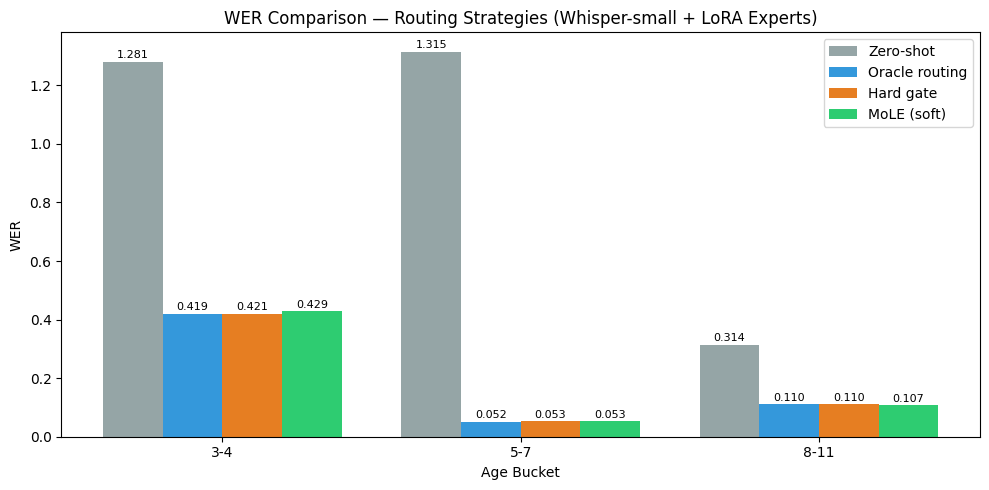

In [25]:
# ── 15. WER comparison bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(AGE_BUCKETS))
w = 0.2

configs = [
    ("Zero-shot",       zs_wer_by_bucket,     "#95a5a6"),
    ("Oracle routing",  oracle_wer_by_bucket,  "#3498db"),
    ("Hard gate",       hard_wer_by_bucket,    "#e67e22"),
    ("MoLE (soft)",     mole_wer_by_bucket,    "#2ecc71"),
]

for i, (label, wer_dict, color) in enumerate(configs):
    vals = [wer_dict[b] for b in AGE_BUCKETS]
    bars = ax.bar(x + i * w, vals, w, label=label, color=color)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + 1.5 * w)
ax.set_xticklabels(AGE_BUCKETS)
ax.set(xlabel="Age Bucket", ylabel="WER",
       title="WER Comparison — Routing Strategies (Whisper-small + LoRA Experts)")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_ROOT / "mole_wer_comparison.png", dpi=100)
plt.show()


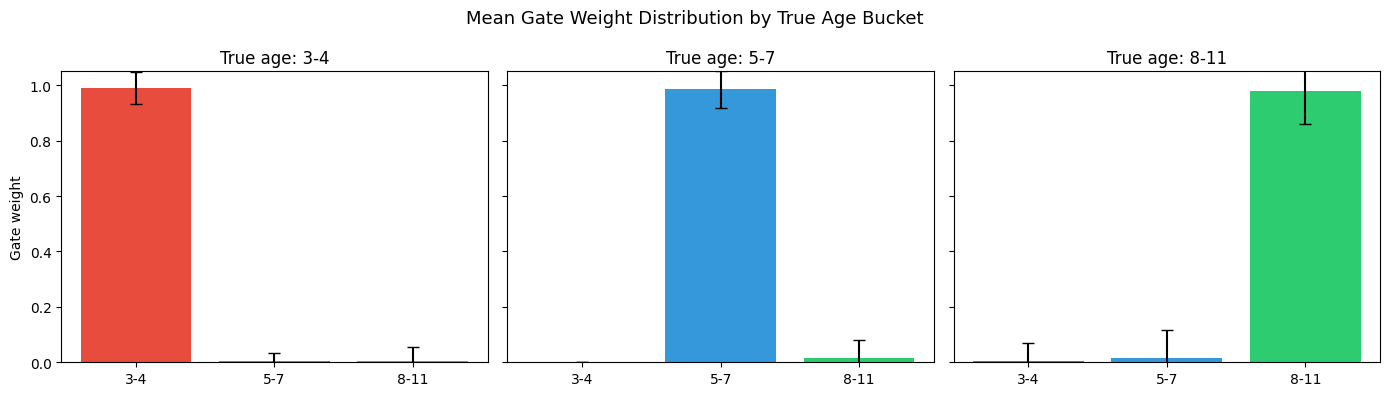

In [26]:
# ── 16. Gate weight distribution by true age bucket ──────────────────────────
df_gate = pd.DataFrame(gate_weight_log)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
colors = ["#e74c3c", "#3498db", "#2ecc71"]

for i, true_bucket in enumerate(AGE_BUCKETS):
    sub = df_gate[df_gate["true_bucket"] == true_bucket]
    means = [sub[b].mean() for b in AGE_BUCKETS]
    stds  = [sub[b].std()  for b in AGE_BUCKETS]
    axes[i].bar(AGE_BUCKETS, means, yerr=stds, color=colors, capsize=4)
    axes[i].set_title(f"True age: {true_bucket}")
    axes[i].set_ylabel("Gate weight" if i == 0 else "")
    axes[i].set_ylim(0, 1.05)

plt.suptitle("Mean Gate Weight Distribution by True Age Bucket", fontsize=13)
plt.tight_layout()
plt.savefig(DATA_ROOT / "mole_gate_weights.png", dpi=100)
plt.show()


In [27]:
# ── 17. Summary ──────────────────────────────────────────────────────────────
print("=" * 65)
print("  SUMMARY — Mixture of LoRA Experts (MoLE)")
print("=" * 65)
print(f"Base model       : {MODEL_NAME}")
print(f"Num experts      : {len(AGE_BUCKETS)} (one LoRA adapter per age bucket)")
print(f"Gate eval acc    : {eval_acc:.4f}")
print(f"Beam search      : {NUM_BEAMS}")
# print(f"Eval per bucket  : {EVAL_N_PER_BUCKET}")
print()
print(f"{'Approach':<20}  {'3-4':>8}  {'5-7':>8}  {'8-11':>8}  {'Overall':>8}")
print("-" * 65)
for label, d, overall in [
    ("Zero-shot",      zs_wer_by_bucket,     zs_wer_overall),
    ("Oracle routing", oracle_wer_by_bucket,  oracle_wer_overall),
    ("Hard gate",      hard_wer_by_bucket,    hard_wer_overall),
    ("MoLE (soft)",    mole_wer_by_bucket,    mole_wer_overall),
]:
    vals = "  ".join(f"{d[b]:>8.4f}" for b in AGE_BUCKETS)
    print(f"{label:<20}  {vals}  {overall:>8.4f}")


  SUMMARY — Mixture of LoRA Experts (MoLE)
Base model       : openai/whisper-small
Num experts      : 3 (one LoRA adapter per age bucket)
Gate eval acc    : 0.9900
Beam search      : 5

Approach                   3-4       5-7      8-11   Overall
-----------------------------------------------------------------
Zero-shot               1.2807    1.3151    0.3142    0.3952
Oracle routing          0.4194    0.0517    0.1102    0.1167
Hard gate               0.4206    0.0531    0.1105    0.1171
MoLE (soft)             0.4285    0.0527    0.1069    0.1140


In [28]:
# ── 18. Load saved MoLE for inference (reuse in another notebook) ────────────
# This cell demonstrates how to reconstruct the full MoLE pipeline from saved
# artifacts: base model + 3 age adapters + gating MLP.

def load_mole(model_name, adapter_dirs, gate_path, device):
    """Load the full MoLE pipeline from saved artifacts."""
    from transformers import WhisperProcessor, WhisperForConditionalGeneration
    from peft import PeftModel
    import torch, torch.nn as nn

    # 1. Processor
    processor = WhisperProcessor.from_pretrained(
        model_name, language="English", task="transcribe"
    )

    # 2. Base model
    base = WhisperForConditionalGeneration.from_pretrained(model_name).to(device)
    forced_ids = processor.get_decoder_prompt_ids(language="english", task="transcribe")
    base.config.forced_decoder_ids   = forced_ids
    base.config.suppress_tokens      = []
    base.generation_config.language   = "english"
    base.generation_config.task       = "transcribe"
    base.generation_config.forced_decoder_ids = forced_ids

    # 3. Load adapters
    buckets = list(adapter_dirs.keys())
    adapter_names = [f"age_{b.replace('-','_')}" for b in buckets]
    model = PeftModel.from_pretrained(
        base, str(adapter_dirs[buckets[0]]), adapter_name=adapter_names[0]
    )
    for b, name in zip(buckets[1:], adapter_names[1:]):
        model.load_adapter(str(adapter_dirs[b]), adapter_name=name)
    model = model.to(device).eval()

    # 4. Load gating MLP
    checkpoint = torch.load(gate_path, map_location=device, weights_only=False)
    cfg = checkpoint["config"]
    gate = GatingMLP(cfg["d_model"], cfg["n_classes"], cfg["hidden"], cfg["dropout"])
    gate.load_state_dict(checkpoint["state_dict"])
    gate = gate.to(device).eval()

    print(f"Loaded MoLE: {len(adapter_names)} adapters + gate")
    print(f"  Gate config: {cfg}")
    return model, gate, processor, adapter_names, cfg["age_buckets"]


# Quick test: reload and transcribe one sample
reloaded_model, reloaded_gate, reloaded_proc, reloaded_adapters, reloaded_buckets = load_mole(
    MODEL_NAME, ADAPTER_DIRS,
    os.path.join(OUTPUT_DIR, "gate_mlp.pt"),
    device,
)

sample = test_data[0]
audio  = load_audio(sample["audio_path"])
text, weights = mole_transcribe(audio, reloaded_model, reloaded_gate,
                                reloaded_proc, device)
print(f"\nSample transcription: {text}")
print(f"Gate weights: {weights}")
print(f"Reference:    {sample['orthographic_text']}")


Loaded MoLE: 3 adapters + gate
  Gate config: {'d_model': 768, 'n_classes': 3, 'hidden': 256, 'dropout': 0.1, 'age_buckets': ['3-4', '5-7', '8-11'], 'adapter_names': ['age_3_4', 'age_5_7', 'age_8_11']}

Sample transcription: no idea
Gate weights: {'3-4': 0.002673117443919182, '5-7': 0.7645697593688965, '8-11': 0.23275712132453918}
Reference:    no idea
